<a href="https://colab.research.google.com/github/kuaci1/Student-DO-Prediction/blob/main/Student_DO_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Interpretation & Clustering
import shap
from sklearn.cluster import KMeans

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# 1. Download Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")

# 2. Automatically detect the CSV file
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset path.")
data_file = csv_files[0]

# 3. Load Dataset
df = pd.read_csv(data_file)

print(f"Dataset loaded successfully. Shape: {df.shape}")
display(df.head())

Using Colab cache for faster access to the 'student-dropout-prediction-dataset' dataset.
Dataset loaded successfully. Shape: (10000, 19)


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
# Display dataset info (data types and non-null counts)
print("Dataset Information:")
df.info()

# Describe numerical features
print("\nNumerical Feature Summary:")
display(df.describe())

# Detect missing values
missing_vals = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_vals[missing_vals > 0])

# Show unique values for categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("\nUnique Values in Categorical Features:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:5]}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-n

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000



Missing Values per Column:
Family_Income          500
Study_Hours_per_Day    500
Stress_Index           500
Parental_Education     511
dtype: int64

Unique Values in Categorical Features:
Gender: 2 unique values -> ['Male' 'Female']
Internet_Access: 2 unique values -> ['Yes' 'No']
Part_Time_Job: 2 unique values -> ['Yes' 'No']
Scholarship: 2 unique values -> ['No' 'Yes']
Semester: 4 unique values -> ['Year 1' 'Year 3' 'Year 4' 'Year 2']
Department: 5 unique values -> ['Arts' 'Engineering' 'CS' 'Business' 'Science']
Parental_Education: 4 unique values -> ['High School' 'Bachelor' 'Master' nan 'PhD']


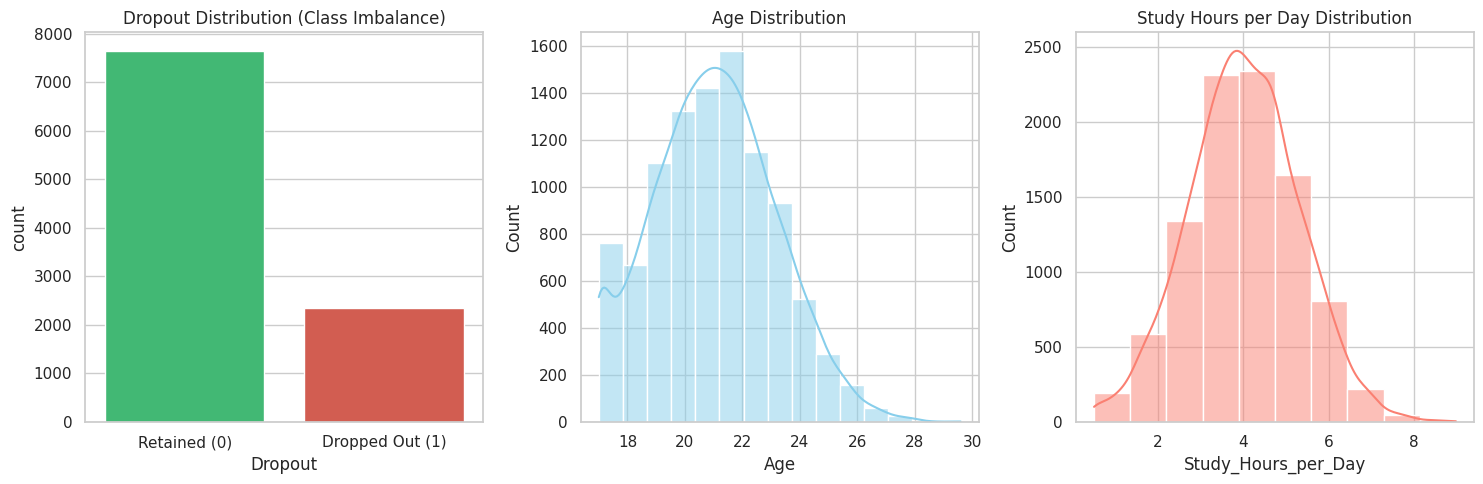

In [ ]:
plt.figure(figsize=(15, 5))

# Target Distribution
plt.subplot(1, 3, 1)
sns.countplot(x='Dropout', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Dropout Distribution (Class Imbalance)')
plt.xticks([0, 1], ['Retained (0)', 'Dropped Out (1)'])

# Age Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')

# Study Hours Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['Study_Hours_per_Day'], bins=10, kde=True, color='salmon')
plt.title('Study Hours per Day Distribution')

plt.tight_layout()
plt.show()

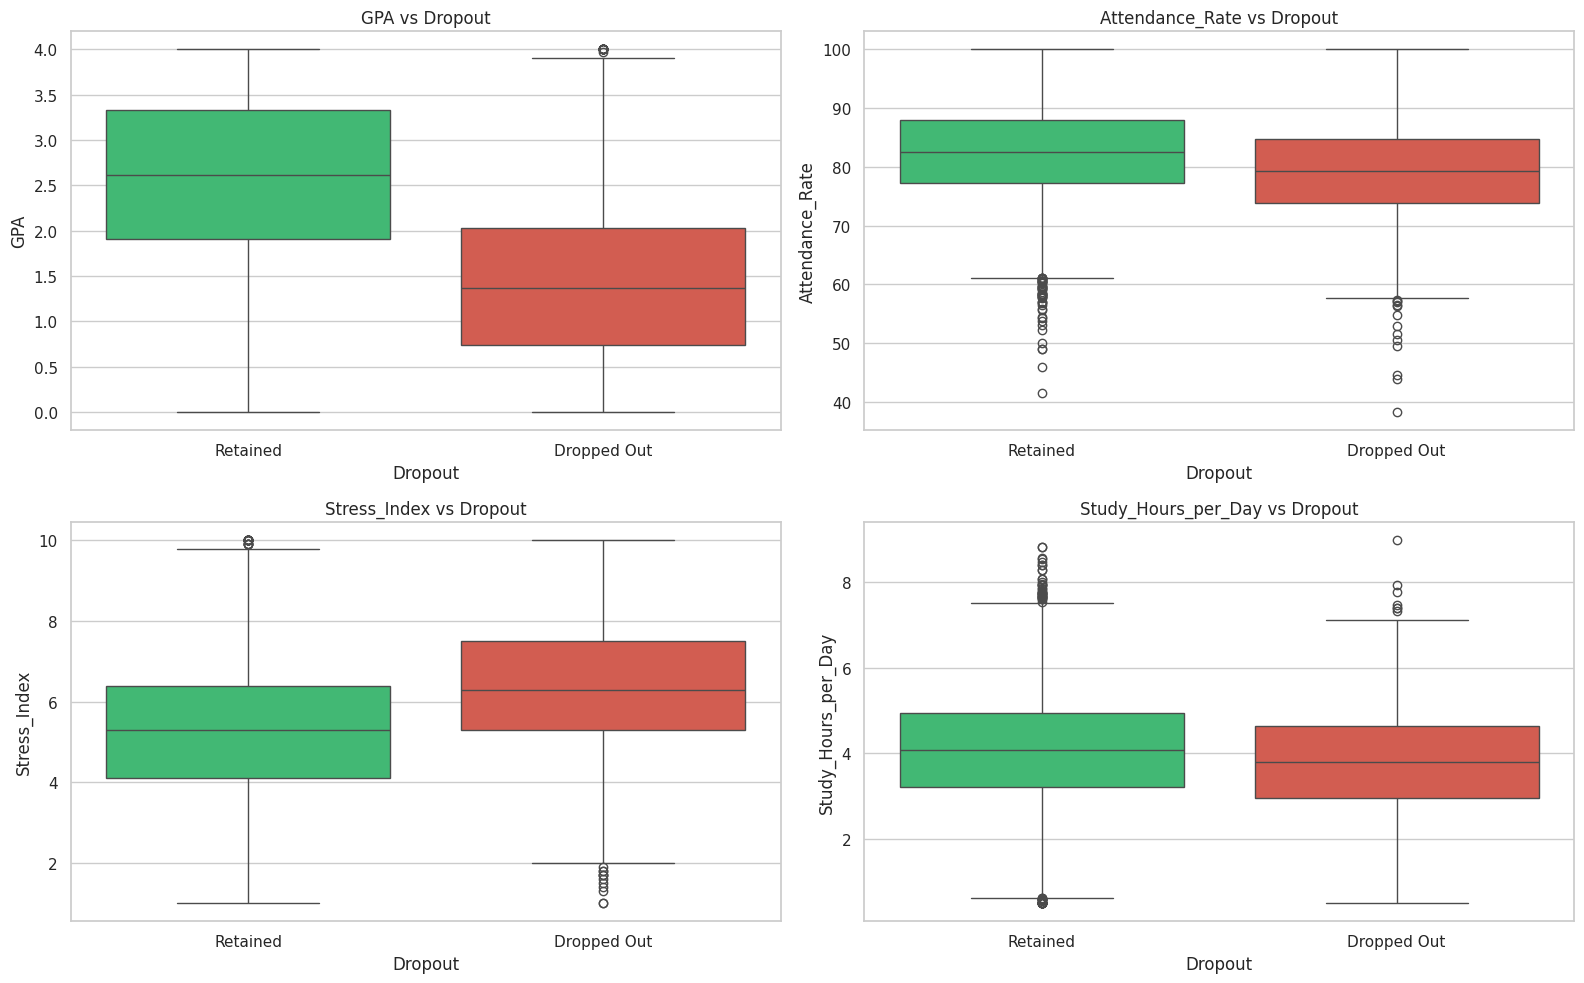

In [ ]:
features_to_plot = ['GPA', 'Attendance_Rate', 'Stress_Index', 'Study_Hours_per_Day']
plt.figure(figsize=(16, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Dropout', y=feature, data=df, palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{feature} vs Dropout')
    plt.xticks([0, 1], ['Retained', 'Dropped Out'])

plt.tight_layout()
plt.show()

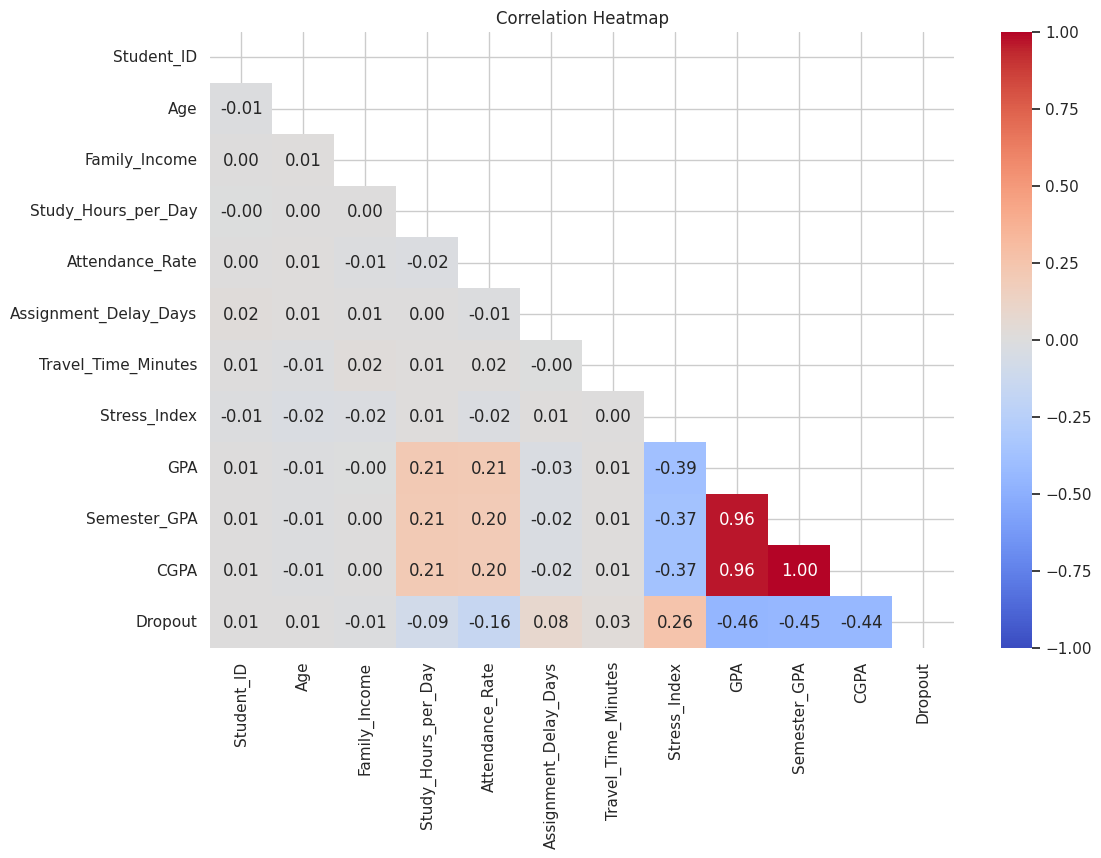

Top features correlated with Dropout:
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Age                      0.007585
Student_ID               0.007434
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64


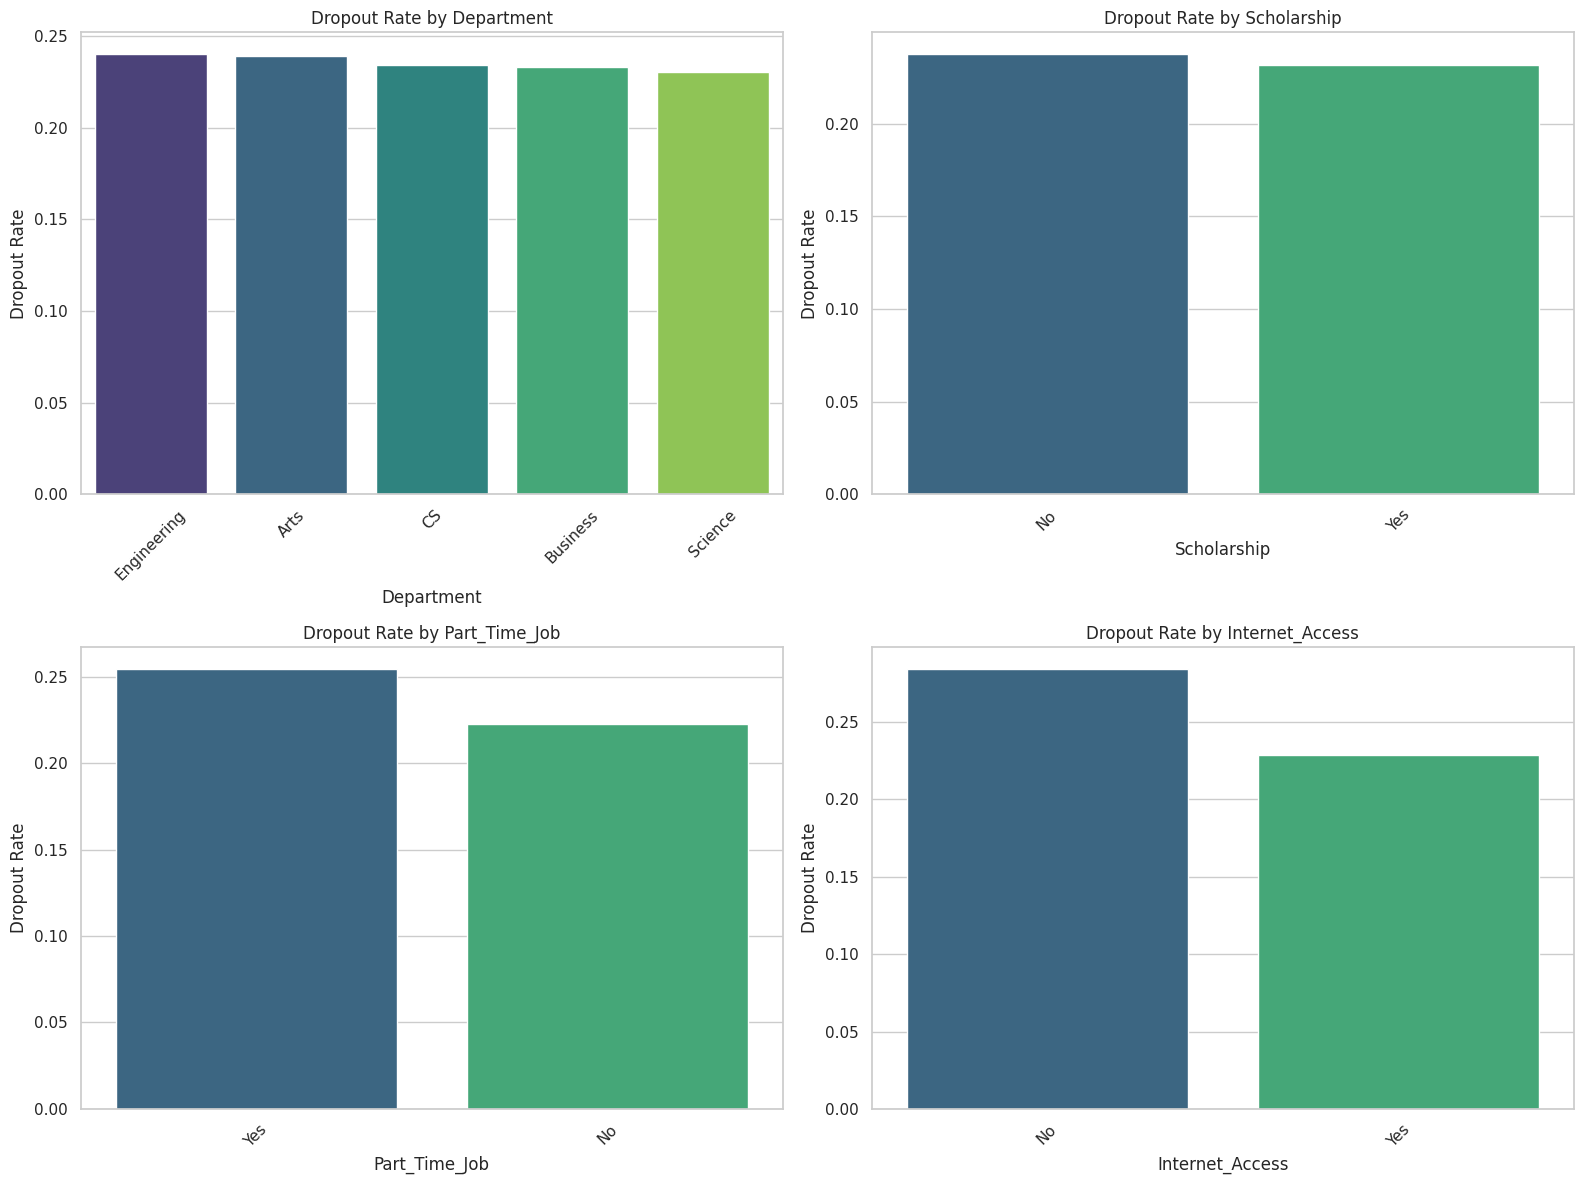

In [ ]:
# Correlation Heatmap for numeric variables
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

# Extract top correlations with Dropout
print("Top features correlated with Dropout:")
print(corr_matrix['Dropout'].sort_values(ascending=False).drop('Dropout'))

# Categorical Impact
cat_features = ['Department', 'Scholarship', 'Part_Time_Job', 'Internet_Access']
plt.figure(figsize=(16, 12))

for i, feature in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    # Calculate dropout rate per category
    dropout_rates = df.groupby(feature)['Dropout'].mean().sort_values(ascending=False)
    sns.barplot(x=dropout_rates.index, y=dropout_rates.values, palette='viridis')
    plt.title(f'Dropout Rate by {feature}')
    plt.ylabel('Dropout Rate')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

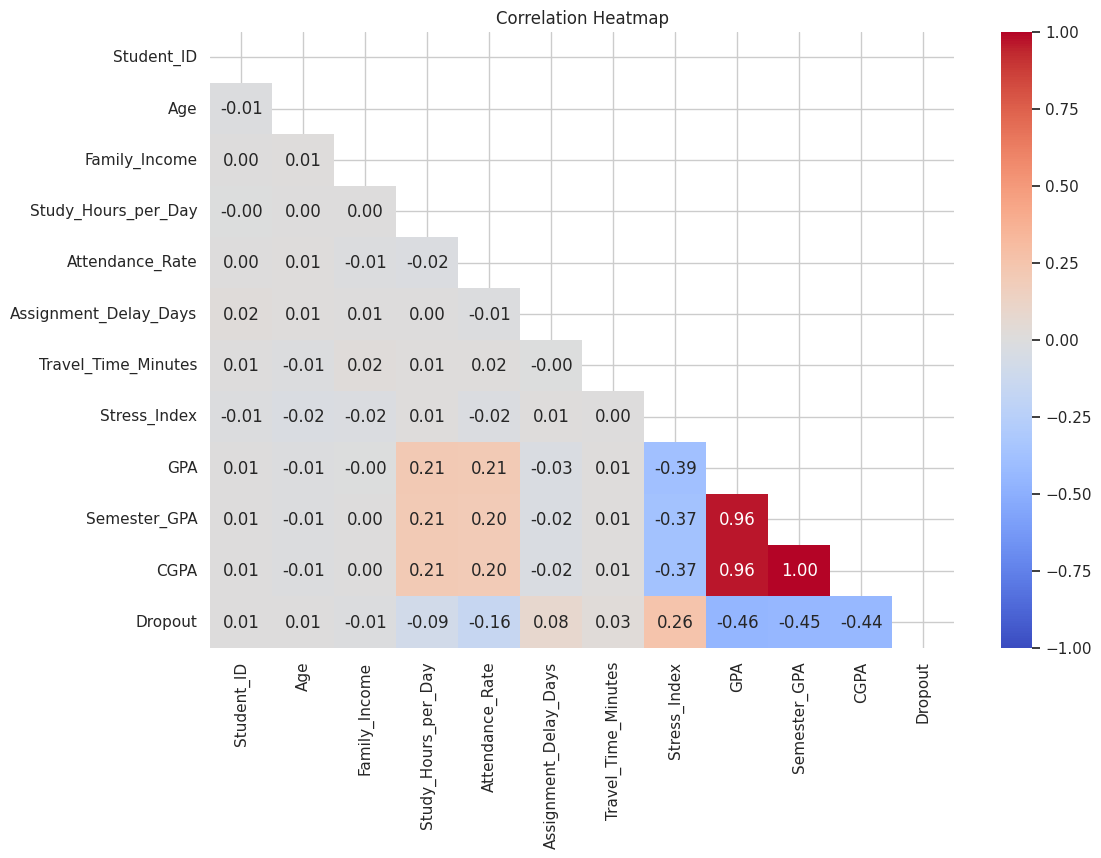

Top features correlated with Dropout:
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Age                      0.007585
Student_ID               0.007434
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64


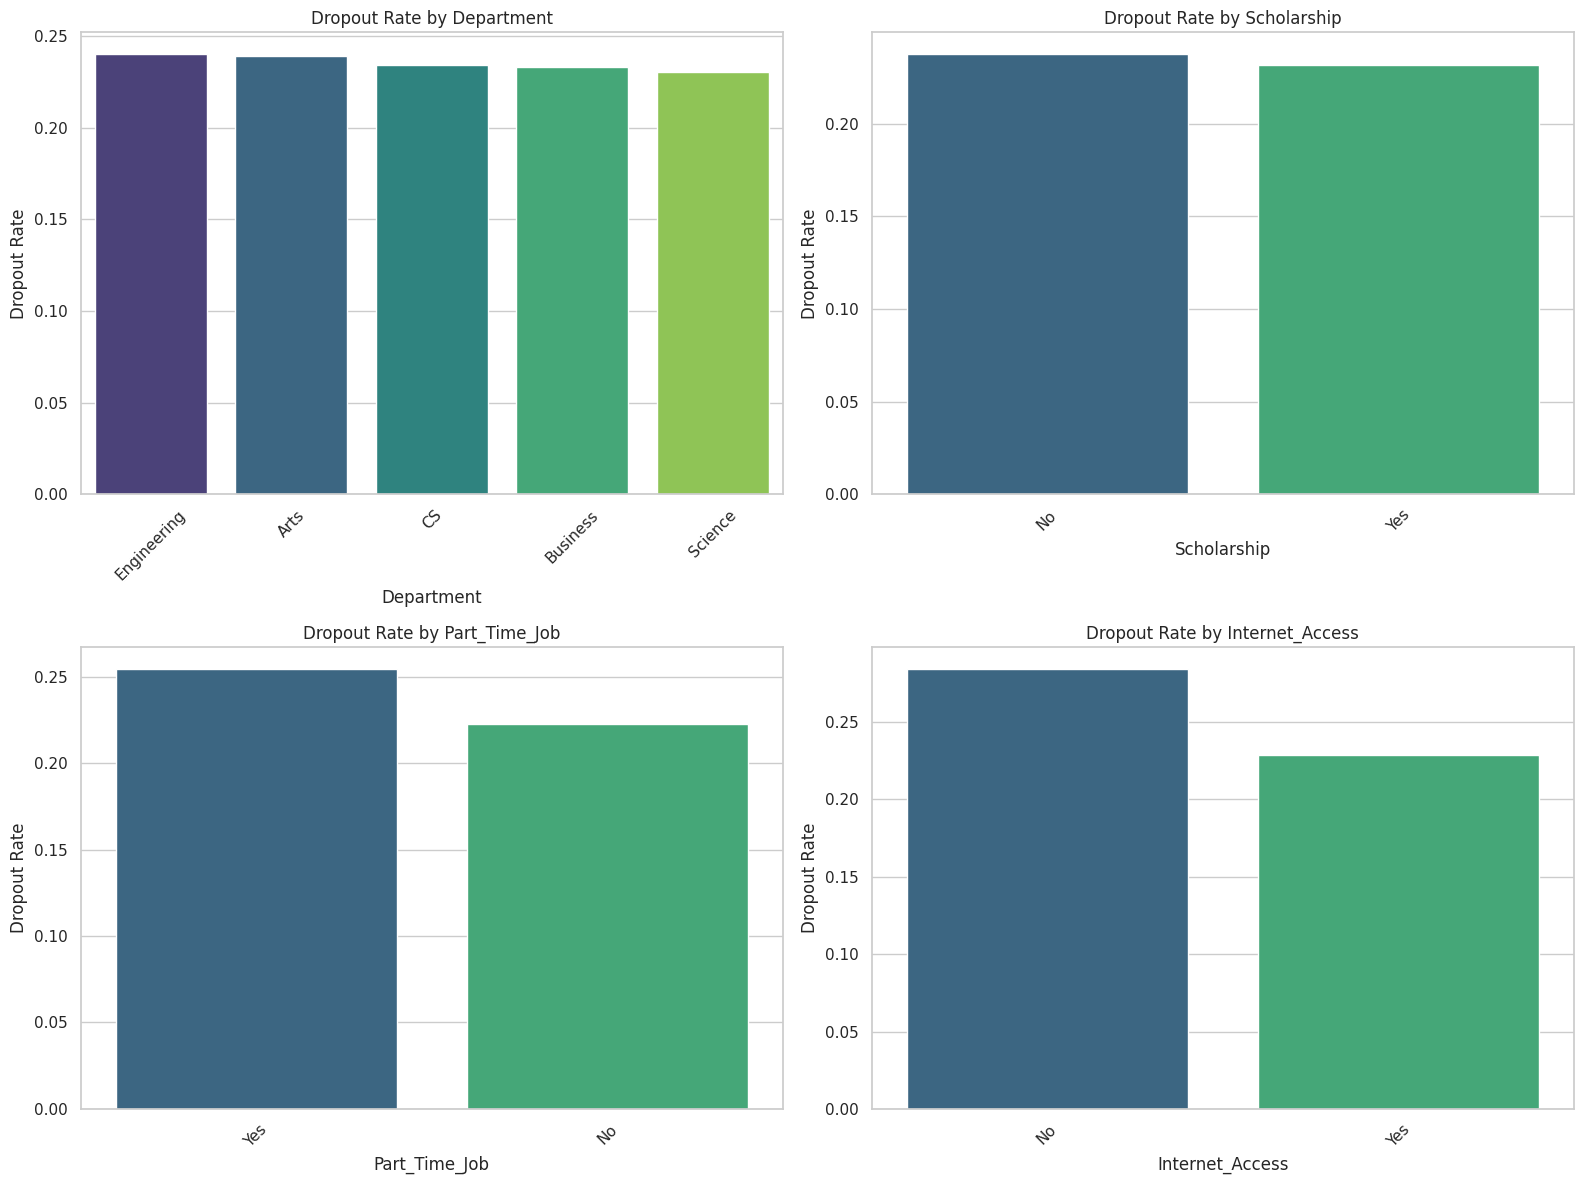

In [ ]:
# Correlation Heatmap for numeric variables
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

# Extract top correlations with Dropout
print("Top features correlated with Dropout:")
print(corr_matrix['Dropout'].sort_values(ascending=False).drop('Dropout'))

# Categorical Impact
cat_features = ['Department', 'Scholarship', 'Part_Time_Job', 'Internet_Access']
plt.figure(figsize=(16, 12))

for i, feature in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    # Calculate dropout rate per category
    dropout_rates = df.groupby(feature)['Dropout'].mean().sort_values(ascending=False)
    sns.barplot(x=dropout_rates.index, y=dropout_rates.values, palette='viridis')
    plt.title(f'Dropout Rate by {feature}')
    plt.ylabel('Dropout Rate')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Drop ID column as it holds no predictive value
if 'Student_ID' in df.columns:
    df = df.drop('Student_ID', axis=1)

# 1. Study Efficiency (Avoid division by zero)
df['Study_Efficiency'] = df['GPA'] / (df['Study_Hours_per_Day'] + 0.1)

# 2. Commute Burden (in hours)
df['Commute_Burden'] = df['Travel_Time_Minutes'] / 60.0

# 3. Academic Performance Gap (Is current semester better or worse than historical?)
df['Academic_Performance_Gap'] = df['Semester_GPA'] - df['CGPA']

# 4. Stress Adjusted GPA
df['Stress_Adjusted_GPA'] = df['GPA'] / (df['Stress_Index'] + 1)

# 5. Attendance to Study Ratio
df['Attendance_Study_Ratio'] = df['Attendance_Rate'] / (df['Study_Hours_per_Day'] + 1)

# 6. Academic Risk Score (Heuristic logic: High stress + High Delay + Low Attendance)
# Normalize inputs min-max style to blend them
norm_stress = df['Stress_Index'] / df['Stress_Index'].max()
norm_delay = df['Assignment_Delay_Days'] / (df['Assignment_Delay_Days'].max() + 1)
norm_absent = (100 - df['Attendance_Rate']) / 100

df['Academic_Risk_Score'] = norm_stress + norm_delay + norm_absent

print("Feature Engineering Complete. New features added.")
display(df[['Study_Efficiency', 'Academic_Performance_Gap', 'Academic_Risk_Score']].head())

Feature Engineering Complete. New features added.


,Study_Efficiency,Academic_Performance_Gap,Academic_Risk_Score
0,0.277457,0.00,0.911222
1,0.290909,0.01,1.222222
2,0.373333,0.00,0.841000
3,NaN,0.00,NaN
4,0.344988,0.04,1.054111


In [ ]:
# Separate features and target
X = df.drop('Dropout', axis=1)
y = df['Dropout']

# Identify column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# Train-Test Split (Stratified to maintain dropout ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Original training shape: {X_train_processed.shape}, Class distribution: {np.bincount(y_train)}")
print(f"Resampled training shape: {X_train_resampled.shape}, Class distribution: {np.bincount(y_train_resampled)}")

Original training shape: (8000, 30), Class distribution: [6117 1883]
Resampled training shape: (12234, 30), Class distribution: [6117 6117]


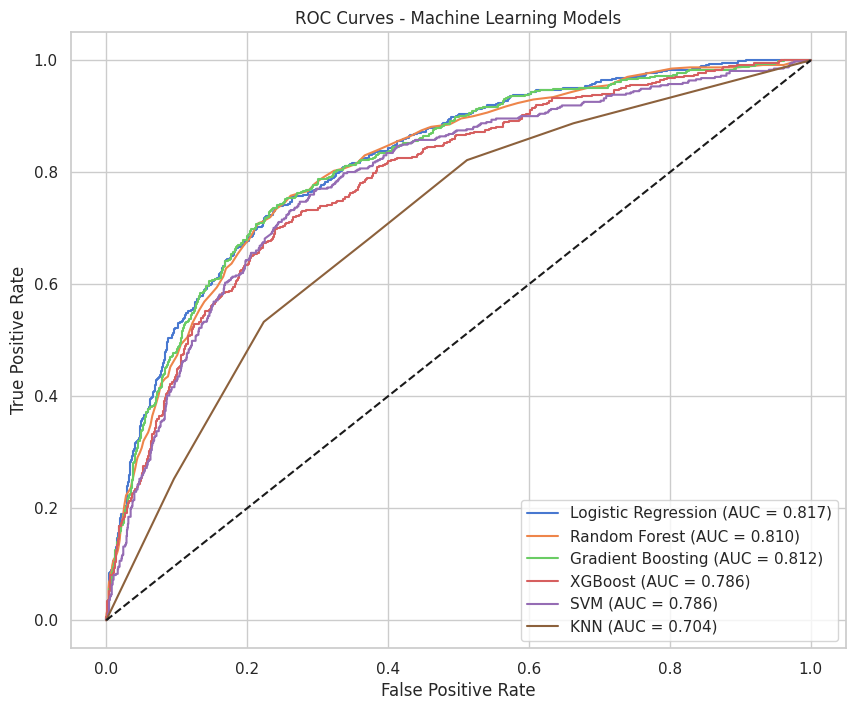

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7390,0.466225,0.747346,0.574225,0.817360
2,Gradient Boosting,0.8025,0.593596,0.511677,0.549601,0.812483
1,Random Forest,0.7940,0.563715,0.554140,0.558887,0.810203
3,XGBoost,0.7920,0.576177,0.441614,0.500000,0.785918
4,SVM,0.7470,0.474820,0.700637,0.566038,0.785893
5,KNN,0.6385,0.359375,0.683652,0.471105,0.704393


In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

plt.figure(figsize=(10, 8))

# Train and evaluate
for name, model in models.items():
    # Train
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Machine Learning Models')
plt.legend(loc='lower right')
plt.show()

# Results Table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
display(results_df.sort_values(by='ROC-AUC', ascending=False))

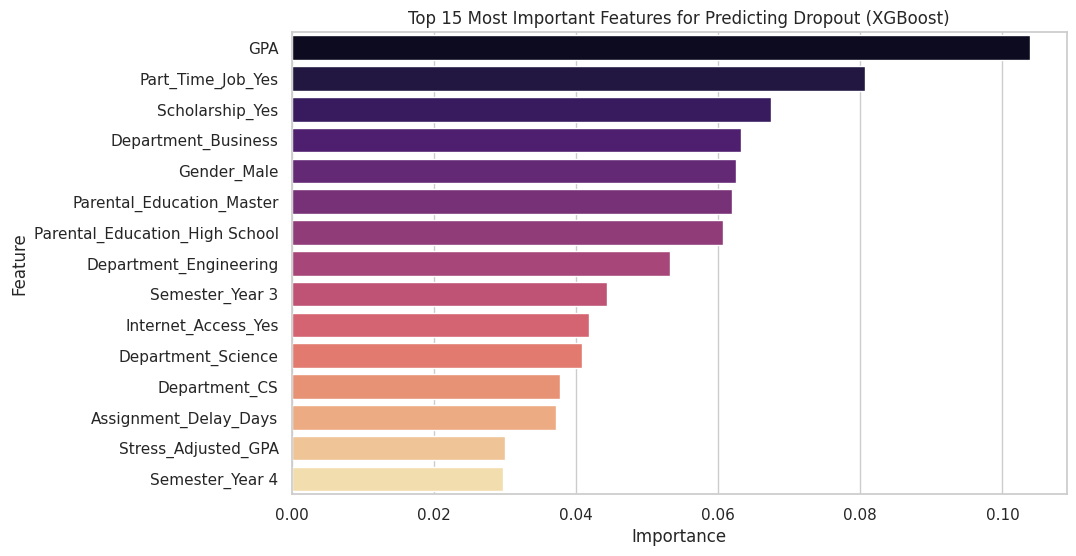

In [ ]:
# Get feature names from ColumnTransformer
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Extract importances from XGBoost
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_

# Create a DataFrame and sort
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Top 15 Most Important Features for Predicting Dropout (XGBoost)')
plt.show()

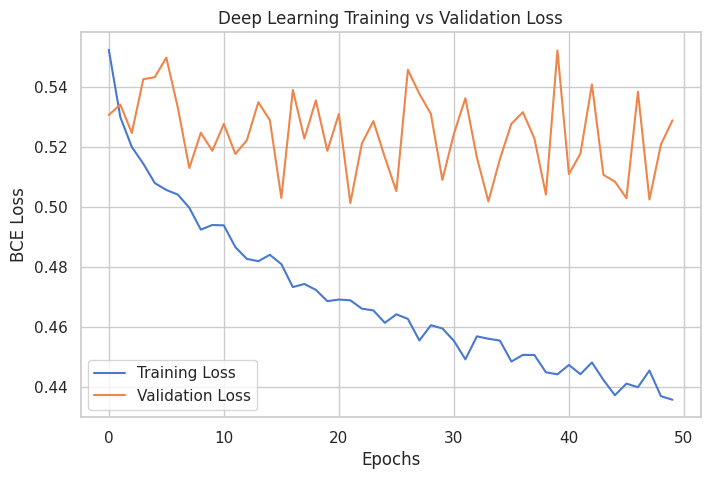

Deep Learning Model Performance:
Accuracy:  0.7455
Precision: 0.4738
Recall:    0.7282
F1-Score:  0.5741
ROC-AUC:   0.8003


In [ ]:
# Convert data to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train_resampled)
y_train_tensor = torch.FloatTensor(y_train_resampled).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define Network Architecture
class DropoutPredictor(nn.Module):
    def __init__(self, input_dim):
        super(DropoutPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Initialize Model, Loss, and Optimizer
input_dim = X_train_tensor.shape[1]
dl_model = DropoutPredictor(input_dim)
criterion = nn.BCELoss() # Binary Cross Entropy for probability output
optimizer = optim.Adam(dl_model.parameters(), lr=0.001)

# Training Loop
epochs = 50
train_losses = []
test_losses = []

for epoch in range(epochs):
    dl_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = dl_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # Validation phase
    dl_model.eval()
    with torch.no_grad():
        test_preds = dl_model(X_test_tensor)
        test_loss = criterion(test_preds, y_test_tensor).item()
        test_losses.append(test_loss)

# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Deep Learning Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.show()

# Evaluate DL Model
dl_model.eval()
with torch.no_grad():
    y_dl_prob = dl_model(X_test_tensor).numpy()
    y_dl_pred = (y_dl_prob >= 0.5).astype(int)

print("Deep Learning Model Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_dl_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_dl_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_dl_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_dl_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_dl_prob):.4f}")

Cluster Profiles (Mean Values):


,Attendance_Rate,Study_Hours_per_Day,Assignment_Delay_Days,Stress_Index,Dropout
Behavior_Cluster,,,,,
0,86.868689,3.595320,1.224526,4.646695,0.141321
1,81.432830,4.017725,3.673804,5.608632,0.288413
2,76.531843,4.467188,1.202317,6.374180,0.300377


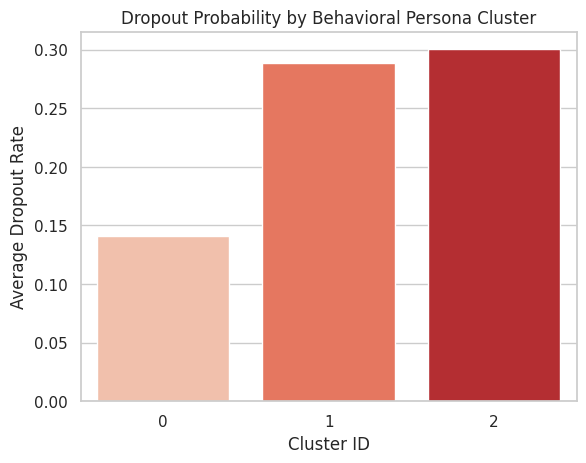

In [ ]:
# Select behavioral features
behavioral_features = ['Attendance_Rate', 'Study_Hours_per_Day', 'Assignment_Delay_Days', 'Stress_Index']
X_behavior = df[behavioral_features].copy()

# Impute missing values before scaling
imputer = SimpleImputer(strategy='median')
X_behavior_imputed = imputer.fit_transform(X_behavior)

# Scale
scaler = StandardScaler()
X_behavior_scaled = scaler.fit_transform(X_behavior_imputed)

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Behavior_Cluster'] = kmeans.fit_predict(X_behavior_scaled)

# Analyze clusters
cluster_summary = df.groupby('Behavior_Cluster')[behavioral_features + ['Dropout']].mean()
print("Cluster Profiles (Mean Values):")
display(cluster_summary)

# Visualizing Clusters by Risk
sns.barplot(x=cluster_summary.index, y=cluster_summary['Dropout'], palette='Reds')
plt.title('Dropout Probability by Behavioral Persona Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Average Dropout Rate')
plt.show()